# Homework 1 — Section 4: Decision Trees

## Step 1: Read the data with pandas

Each TSV file has a header row. The last column contains the class label, and the other columns contain the features (Section 4.1 of the handout).

Run this notebook from its `Programming` folder. The supplied validation files use `_val.tsv` in their names.


In [ ]:
import pandas as pd

small_train = pd.read_csv("small_train.tsv", sep="\t")
small_val = pd.read_csv("small_val.tsv", sep="\t")

heart_train = pd.read_csv("heart_train.tsv", sep="\t")
heart_val = pd.read_csv("heart_val.tsv", sep="\t")

education_train = pd.read_csv("education_train.tsv", sep="\t")
education_val = pd.read_csv("education_val.tsv", sep="\t")


### Inspect the small dataset

`head()` displays the first five rows, including the column names. Here, `chest_pain` and `thalassemia` are features; `heart_disease` is the label we will predict.


In [ ]:
small_train.head()


### Check dataset sizes

Each DataFrame's `shape` gives `(number of rows, number of columns)`. The column count includes the label.


In [ ]:
print("Small:", small_train.shape, small_val.shape)
print("Heart:", heart_train.shape, heart_val.shape)
print("Education:", education_train.shape, education_val.shape)


## Step 2: Calculate entropy

Entropy measures how mixed the labels are at a node (Section 4.2.1 of the handout).

$$H(Y) = -\sum_y p(y)\log_2 p(y)$$

For binary labels, entropy is **0 bits** when every label is the same and **1 bit** when the labels are evenly split.

`value_counts(normalize=True)` gives the proportion of each observed label. We use those proportions in the formula. Since only observed labels are included, we never take the logarithm of zero. For an empty group, we return 0 so it contributes nothing when we later calculate a split's weighted entropy.


In [ ]:
from math import log2


def entropy(labels):
    """Calculate entropy in bits for a pandas Series of labels."""
    if labels.empty:
        return 0.0

    probabilities = labels.value_counts(normalize=True)
    return -sum(p * log2(p) for p in probabilities)


### Try a few examples

The small training dataset has 14 zeros and 14 ones, so its label entropy should be 1 bit. `iloc[:, -1]` selects the last column, which contains the labels.


In [ ]:
print("All labels the same:", entropy(pd.Series([1, 1, 1, 1])))
print("Evenly split labels:", entropy(pd.Series([0, 0, 1, 1])))
print("Mostly one label:", entropy(pd.Series([0, 1, 1, 1])))
print("Small training labels:", entropy(small_train.iloc[:, -1]))


Next, we will use entropy to calculate **mutual information**: how much a feature split reduces label uncertainty.


## Step 3: Calculate mutual information

Mutual information (also called information gain here) measures how much splitting on a feature reduces label uncertainty. Section 4.2 requires this weighted calculation:

$$I(Y;X) = H(Y) - P(X=0)H(Y\mid X=0) - P(X=1)H(Y\mid X=1)$$

We split the DataFrame into two groups using the feature's value. Each group's weight is its fraction of the total rows, so larger groups contribute more to the remaining uncertainty. Subtracting that weighted entropy from the original entropy gives the information gain.


In [ ]:
def mutual_information(data, feature):
    """Calculate information gain for a binary feature; the last column is the label."""
    if data.empty:
        return 0.0

    labels = data.iloc[:, -1]
    group_0 = data[data[feature] == 0]
    group_1 = data[data[feature] == 1]

    weight_0 = len(group_0) / len(data)
    weight_1 = len(group_1) / len(data)

    entropy_after_split = (
        weight_0 * entropy(group_0.iloc[:, -1])
        + weight_1 * entropy(group_1.iloc[:, -1])
    )
    return entropy(labels) - entropy_after_split


### Compare the small dataset's features

`columns[:-1]` selects all feature names, excluding the label column. A larger gain means the split removes more uncertainty. We use the training data to evaluate splits.


In [ ]:
for feature in small_train.columns[:-1]:
    gain = mutual_information(small_train, feature)
    print(f"{feature}: {gain:.6f} bits")


`chest_pain` has the larger information gain, so it is the preferred root split. This agrees with the small-tree example in Section 4.2.2.

Next, we will choose the best feature automatically. The handout requires choosing the first column when gains tie and only splitting when the best gain is greater than the threshold (0 by default).


## Step 4: Choose the best feature

We compare the information gain of each feature in column order. Section 4.2 gives two rules:

- Only split if the information gain is **greater than** the threshold (0 by default).
- If multiple features have the same gain, choose the **first column**.

Starting `best_gain` at the threshold ensures that a feature must beat it to be selected. Updating only when `gain > best_gain` keeps the earlier feature when gains tie. If no feature qualifies, we return `None`, meaning this node should become a leaf.


In [ ]:
def best_feature(data, threshold=0.0):
    """Return the best feature name, or None if no gain exceeds the threshold."""
    chosen_feature = None
    best_gain = threshold

    for feature in data.columns[:-1]:
        gain = mutual_information(data, feature)
        if gain > best_gain:
            chosen_feature = feature
            best_gain = gain

    return chosen_feature


### Try it on the small dataset

At the default threshold, we should choose `chest_pain`. At a threshold of 0.30 bits, neither feature qualifies because both gains are below 0.30.


In [ ]:
print("Default threshold:", best_feature(small_train))
print("Threshold of 0.30:", best_feature(small_train, threshold=0.30))


Next, we will define how a leaf predicts its label using majority vote, including the required rule that a tie predicts 1.


## Step 5: Predict with majority vote

A leaf predicts the most common training label among the examples that reach it. Section 4.2 requires choosing **1 when the counts tie**.

For a pandas Series, `labels == 0` marks each zero as `True`. Summing those values counts the zeros; the same approach counts the ones. Using `>=` makes a tie choose 1.


In [ ]:
def majority_vote(labels):
    """Return the majority binary label, choosing 1 when the counts tie."""
    count_0 = (labels == 0).sum()
    count_1 = (labels == 1).sum()

    if count_1 >= count_0:
        return 1
    return 0


### Try a few examples

The small training dataset has 14 zeros and 14 ones, so its majority vote is 1. A tree with maximum depth 0 would make this same prediction for every example because it never splits.


In [ ]:
print("Mostly zeros:", majority_vote(pd.Series([0, 0, 0, 1])))
print("Mostly ones:", majority_vote(pd.Series([0, 1, 1, 1])))
print("Tied labels:", majority_vote(pd.Series([0, 0, 1, 1])))
print("Small training labels:", majority_vote(small_train.iloc[:, -1]))


Next, we will define a tree node to store its prediction, label counts, split feature, and children.


## Step 6: Define a tree node

Section 4.2.1 suggests representing the tree as a collection of nodes. Each node holds information about the training examples that reach it:

- `count_0` and `count_1`: label counts, which we will use when printing the tree.
- `prediction`: the majority label, which the node predicts if it is a leaf.
- `feature`: the feature used to split, or `None` for a leaf.
- `left` and `right`: child nodes for feature values 0 and 1, respectively.

Every node starts as a leaf. When we build the tree, we can give it a split feature and two children. We keep the majority prediction even at internal nodes so we can later turn a subtree into a leaf during pruning.

`__init__` runs when we create a node, and `self` refers to that particular node.


In [ ]:
class Node:
    """A decision tree node, initially a leaf."""

    def __init__(self, labels):
        self.count_0 = int((labels == 0).sum())
        self.count_1 = int((labels == 1).sum())
        self.prediction = majority_vote(labels)

        self.feature = None
        self.left = None
        self.right = None


### Create a root node

The root receives all training examples. For the small dataset, its counts should be 14 zeros and 14 ones, and its prediction should be 1. This example only creates the node; it does not split the data yet.


In [ ]:
root = Node(small_train.iloc[:, -1])

print(f"Label counts: [{root.count_0} 0/{root.count_1} 1]")
print("Prediction:", root.prediction)
print("Split feature:", root.feature)
print("Children:", root.left, root.right)


Next, we will build the tree recursively: create a node, check the stopping rules, choose a feature, and repeat for its two groups.


## Step 7: Build the tree recursively

Each call builds one node from the training rows that reach it. We start by creating a leaf with a majority prediction, then stop if:

- The node has reached the maximum depth. The root is at depth 0.
- All labels at the node are the same.
- No feature has information gain greater than the threshold.

Otherwise, we choose the best feature and split the rows into groups for values 0 and 1. We call the same function on each group to build the left and right children. This is **recursion**: each smaller group is handled using the same steps.

`max_depth=None` means no depth limit. After splitting, we drop the chosen feature from each group because it is constant within that branch. The remaining columns stay in their original order, and the label stays last. When no features remain, `best_feature()` returns `None`.


In [ ]:
def build_tree(data, max_depth=None, threshold=0.0, depth=0, min_size=0):
    """Build a binary decision tree from a nonempty training DataFrame."""
    labels = data.iloc[:, -1]
    node = Node(labels)

    if max_depth is not None and depth >= max_depth:
        return node

    if len(data) < min_size:
        return node

    if labels.nunique() == 1:
        return node

    feature = best_feature(data, threshold)
    if feature is None:
        return node

    node.feature = feature
    group_0 = data[data[feature] == 0].drop(columns=feature)
    group_1 = data[data[feature] == 1].drop(columns=feature)

    node.left = build_tree(
        group_0, max_depth=max_depth, threshold=threshold, depth=depth + 1,
        min_size=min_size
    )
    node.right = build_tree(
        group_1, max_depth=max_depth, threshold=threshold, depth=depth + 1,
        min_size=min_size
    )
    return node


### Build the small tree

With maximum depth 2, the root should split on `chest_pain`, and both children should split on `thalassemia`, matching Section 4.2.2. With maximum depth 0, the root stays a leaf and predicts 1.


In [ ]:
small_tree = build_tree(small_train, max_depth=2)

print("Root split:", small_tree.feature)
print("Split where chest_pain = 0:", small_tree.left.feature)
print("Split where chest_pain = 1:", small_tree.right.feature)

depth_0_tree = build_tree(small_train, max_depth=0)
print("\nDepth-0 split:", depth_0_tree.feature)
print("Depth-0 prediction:", depth_0_tree.prediction)


Next, we will print the full tree with indentation and label counts in the format required by Section 4.2.2.


## Step 8: Print the tree

Section 4.2.2 asks us to print each node before its children. This is a **pre-order depth-first traversal**: print the current node, then its left subtree, then its right subtree.

The root line contains only its label counts. Every other line shows the parent's split feature, the branch value that led to this node, and this node's label counts. We repeat `"| "` once per depth level to show the tree's structure.

For example, `| chest_pain = 0: [4 0/12 1]` means that the root's value-0 branch contains 4 label-0 examples and 12 label-1 examples. The feature printed on this line describes how we reached the node, rather than the node's own next split.


In [ ]:
def print_tree(node, depth=0, parent_feature=None, branch_value=None):
    """Print a trained tree in pre-order, with indentation and label counts."""
    counts = f"[{node.count_0} 0/{node.count_1} 1]"

    if parent_feature is None:
        print(counts)
    else:
        indent = "| " * depth
        print(f"{indent}{parent_feature} = {branch_value}: {counts}")

    if node.feature is not None:
        print_tree(node.left, depth + 1, node.feature, 0)
        print_tree(node.right, depth + 1, node.feature, 1)


### Print the small tree

This depth-2 tree should match the small dataset example in Section 4.2.2. Printing happens after training is complete.


In [ ]:
print_tree(small_tree)


A depth-0 tree is just one leaf, so its output contains only the root counts.


In [ ]:
print_tree(depth_0_tree)


Next, we will use a trained tree to predict labels for new rows, then calculate training and validation error.


## Step 9: Predict labels and calculate error

To predict one row, start at the root and look up the row's value for the split feature. Follow the left child for 0 or the right child for 1. Repeat until reaching a leaf, then return its majority prediction.

Predictions use only the features. The true labels are used afterward to evaluate the predictions, as required by Section 4.2.


In [ ]:
def predict_one(tree, row):
    """Follow one row through the tree and return the leaf's prediction."""
    node = tree

    while node.feature is not None:
        if row[node.feature] == 0:
            node = node.left
        else:
            node = node.right

    return node.prediction


def predict(tree, features):
    """Return a pandas Series of predictions, one for each feature row."""
    return features.apply(lambda row: predict_one(tree, row), axis=1)


### Measure mistakes

`apply(..., axis=1)` runs our prediction function on each row and preserves its index.

The error rate is the fraction of predictions that are wrong. Comparing the label and prediction Series gives `True` for mistakes; `.mean()` computes their fraction. The two Series must refer to the same rows with matching indexes. Accuracy is `1 - error`.


In [ ]:
def error_rate(labels, predictions):
    """Return the fraction of incorrect predictions for matching row indexes."""
    return (labels != predictions).mean()


### Evaluate the small tree

`iloc[:, :-1]` selects the feature columns, while `iloc[:, -1]` selects the labels. We use the same trained tree for both datasets; validation rows do not change the tree.


In [ ]:
small_train_predictions = predict(small_tree, small_train.iloc[:, :-1])
small_val_predictions = predict(small_tree, small_val.iloc[:, :-1])

train_error = error_rate(small_train.iloc[:, -1], small_train_predictions)
val_error = error_rate(small_val.iloc[:, -1], small_val_predictions)

print(f"Training error: {train_error:.6f}")
print(f"Validation error: {val_error:.6f}")
print(f"Training accuracy: {1 - train_error:.2%}")
print(f"Validation accuracy: {1 - val_error:.2%}")


Compare the first few validation predictions with their true labels:


In [ ]:
pd.DataFrame({
    "Actual": small_val.iloc[:, -1],
    "Predicted": small_val_predictions,
}).head()


The supplied `example_output/small_3_metrics.txt` reports the same errors (its `test` split corresponds to our validation split). Although that example uses maximum depth 3, the small dataset has only two features, so increasing the limit from 2 to 3 does not change this tree.

Next, we can answer Section 4.3, Question 1: report validation accuracy for all three datasets with no maximum depth limit and the default information gain threshold.


## Section 4.3 — Question 1: Validation accuracy

Train a separate decision tree on each dataset using **no maximum depth limit** and the default **information gain threshold of 0**. Then report its accuracy on the corresponding validation set.

`max_depth=None` removes the depth limit. The other stopping rules still apply: pure labels or no positive information gain stop a branch. Each tree learns from training rows only.


In [ ]:
datasets = [
    ("small", small_train, small_val),
    ("heart", heart_train, heart_val),
    ("education", education_train, education_val),
]

results = []
for name, train_data, val_data in datasets:
    tree = build_tree(train_data, max_depth=None, threshold=0.0)
    predictions = predict(tree, val_data.iloc[:, :-1])
    accuracy = 1 - error_rate(val_data.iloc[:, -1], predictions)

    results.append({
        "Dataset": name,
        "Validation accuracy (%)": 100 * accuracy,
    })

accuracy_results = pd.DataFrame(results)
accuracy_results.round(2)


### Answer

- **small**: 71.43%
- **heart**: 74.23%
- **education**: 100.00%

Next, Question 2 asks us to print the heart dataset tree with maximum depth 4.


## Section 4.3 — Question 2: Heart tree with maximum depth 4

Train on `heart_train` with `max_depth=4` and the default information gain threshold of 0. The root is at depth 0, so nodes at depth 4 must be leaves; some branches may stop earlier.

The printed tree below is the answer to Question 2. Each line shows training label counts, following the format in Section 4.2.2. We keep this tree as `heart_tree_depth4` for the pruning question next.


In [24]:
heart_tree_depth4 = build_tree(heart_train, max_depth=4, threshold=0.0)
print_tree(heart_tree_depth4)


[102 0/98 1]
| thalassemia = 0: [81 0/22 1]
| | chest_pain = 0: [17 0/17 1]
| | | fluoroscopy = 0: [14 0/4 1]
| | | | angina = 0: [10 0/0 1]
| | | | angina = 1: [4 0/4 1]
| | | fluoroscopy = 1: [3 0/13 1]
| | | | sex = 0: [3 0/2 1]
| | | | sex = 1: [0 0/11 1]
| | chest_pain = 1: [64 0/5 1]
| | | flat_ST = 0: [14 0/3 1]
| | | | abnormal_ecg = 0: [7 0/0 1]
| | | | abnormal_ecg = 1: [7 0/3 1]
| | | flat_ST = 1: [50 0/2 1]
| | | | sex = 0: [25 0/0 1]
| | | | sex = 1: [25 0/2 1]
| thalassemia = 1: [21 0/76 1]
| | fluoroscopy = 0: [17 0/23 1]
| | | angina = 0: [13 0/8 1]
| | | | flat_ST = 0: [4 0/6 1]
| | | | flat_ST = 1: [9 0/2 1]
| | | angina = 1: [4 0/15 1]
| | | | sex = 0: [0 0/2 1]
| | | | sex = 1: [4 0/13 1]
| | fluoroscopy = 1: [4 0/53 1]
| | | abnormal_ecg = 0: [4 0/22 1]
| | | | flat_ST = 0: [1 0/15 1]
| | | | flat_ST = 1: [3 0/7 1]
| | | abnormal_ecg = 1: [0 0/31 1]


Next, Question 3 asks us to use the heart validation data for reduced error pruning, choosing the smaller tree when validation errors tie.


## Section 4.3 — Question 3: Reduced error pruning

We prune the depth-4 heart tree using `heart_val`. At each internal node, compare the validation mistakes made by its subtree with those made by a single leaf predicting the node's stored **training majority label**.

We work from the bottom up: prune the children first, then consider their parent. Only validation rows that reach a node are used in its comparison. Replace the subtree with a leaf if doing so makes **no more mistakes**; this chooses the smaller tree on ties.

If no validation rows reach a node, both choices make zero validation mistakes, so we replace that subtree with a leaf. Training label counts and majority predictions stay unchanged.


In [ ]:
def prune_tree(node, validation_data):
    """Prune a tree in place, preferring a leaf when validation errors tie."""
    if node.feature is None:
        return node

    if validation_data.empty:
        node.feature = None
        node.left = None
        node.right = None
        return node

    group_0 = validation_data[validation_data[node.feature] == 0]
    group_1 = validation_data[validation_data[node.feature] == 1]

    node.left = prune_tree(node.left, group_0)
    node.right = prune_tree(node.right, group_1)

    labels = validation_data.iloc[:, -1]
    predictions = predict(node, validation_data.iloc[:, :-1])
    subtree_errors = (labels != predictions).sum()
    leaf_errors = (labels != node.prediction).sum()

    if leaf_errors <= subtree_errors:
        node.feature = None
        node.left = None
        node.right = None

    return node


### Prune and print the heart tree

`deepcopy` makes a separate copy so the original Question 2 tree remains available. The printed result is the answer to Question 3.


In [26]:
from copy import deepcopy

pruned_heart_tree = prune_tree(deepcopy(heart_tree_depth4), heart_val)
print_tree(pruned_heart_tree)


[102 0/98 1]
| thalassemia = 0: [81 0/22 1]
| | chest_pain = 0: [17 0/17 1]
| | | fluoroscopy = 0: [14 0/4 1]
| | | fluoroscopy = 1: [3 0/13 1]
| | chest_pain = 1: [64 0/5 1]
| thalassemia = 1: [21 0/76 1]
| | fluoroscopy = 0: [17 0/23 1]
| | | angina = 0: [13 0/8 1]
| | | angina = 1: [4 0/15 1]
| | fluoroscopy = 1: [4 0/53 1]


### Compare validation accuracy

Pruning should not increase validation error. These validation data guide pruning, so the resulting accuracy is not an independent test-set estimate.


In [27]:
before_predictions = predict(heart_tree_depth4, heart_val.iloc[:, :-1])
after_predictions = predict(pruned_heart_tree, heart_val.iloc[:, :-1])

before_accuracy = 1 - error_rate(heart_val.iloc[:, -1], before_predictions)
after_accuracy = 1 - error_rate(heart_val.iloc[:, -1], after_predictions)

print(f"Validation accuracy before pruning: {before_accuracy:.2%}")
print(f"Validation accuracy after pruning: {after_accuracy:.2%}")


Validation accuracy before pruning: 74.23%
Validation accuracy after pruning: 82.47%


Next, Question 4 asks us to plot training and validation accuracy for heart trees with maximum depths from 0 through 8.


## Section 4.3 — Question 4: Maximum depth and accuracy

Train a fresh heart tree at each maximum depth from **0 through 8**, using the default information gain threshold of 0. For each tree, measure training and validation accuracy. These trees are not pruned: we are examining the effect of the depth limit alone.

Depth 0 gives a majority-vote classifier. As depth increases, the tree can learn more detailed patterns in the training data.


In [28]:
depth_results = []

for depth in range(9):
    tree = build_tree(heart_train, max_depth=depth, threshold=0.0)

    train_predictions = predict(tree, heart_train.iloc[:, :-1])
    val_predictions = predict(tree, heart_val.iloc[:, :-1])

    train_accuracy = 1 - error_rate(heart_train.iloc[:, -1], train_predictions)
    val_accuracy = 1 - error_rate(heart_val.iloc[:, -1], val_predictions)

    depth_results.append({
        "Maximum depth": depth,
        "Training accuracy": train_accuracy,
        "Validation accuracy": val_accuracy,
    })

depth_results = pd.DataFrame(depth_results)
depth_results.round(4)


,Maximum depth,Training accuracy,Validation accuracy
0,0,0.510,0.5979
1,1,0.785,0.7216
2,2,0.785,0.6701
3,3,0.860,0.8247
4,4,0.875,0.7423
5,5,0.915,0.7423
6,6,0.920,0.7526
7,7,0.930,0.7423
8,8,0.930,0.7423


### Plot both accuracies

Both curves use the same axes so we can compare how well each tree fits its training data and predicts validation labels.


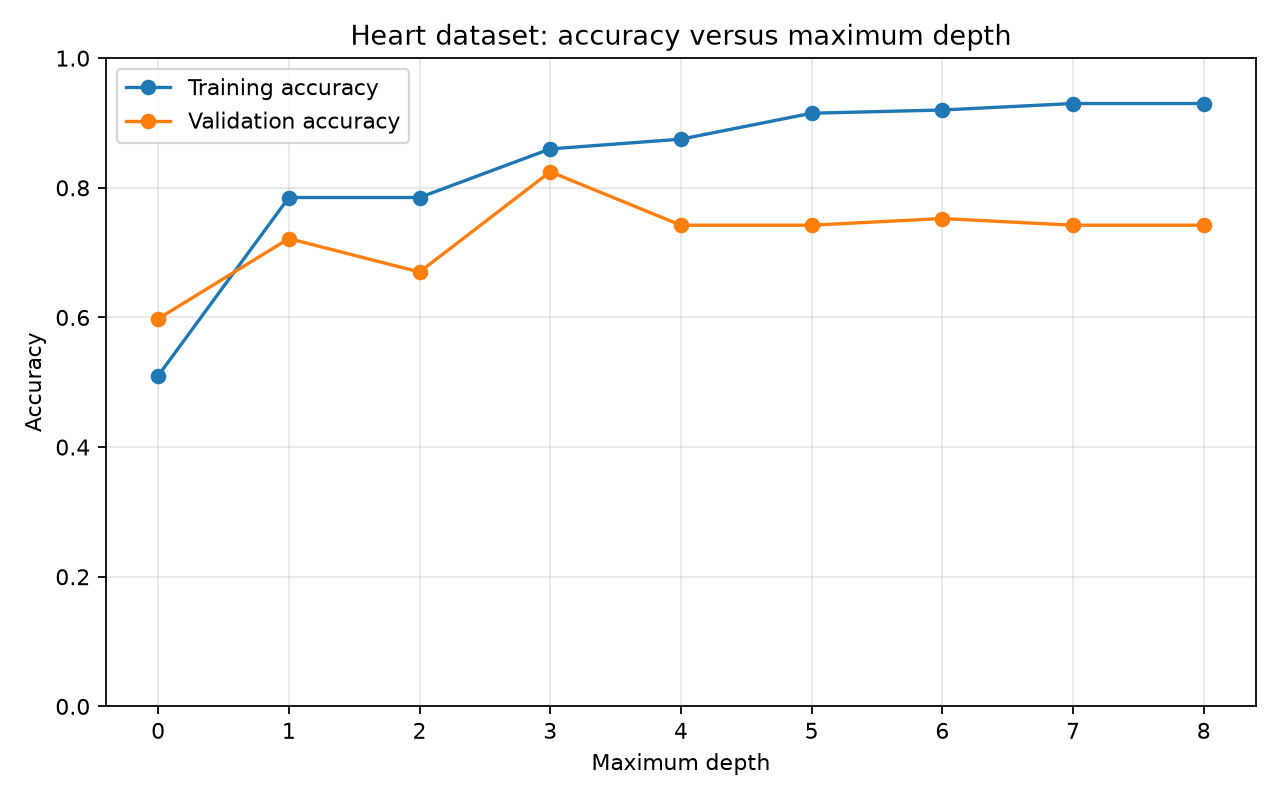

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_results["Maximum depth"], depth_results["Training accuracy"],
        marker="o", label="Training accuracy")
ax.plot(depth_results["Maximum depth"], depth_results["Validation accuracy"],
        marker="o", label="Validation accuracy")

ax.set_xlabel("Maximum depth")
ax.set_ylabel("Accuracy")
ax.set_title("Heart dataset: accuracy versus maximum depth")
ax.set_xticks(range(9))
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


### Find the best depth and check monotonicity

Here, monotonically increasing means **nondecreasing**: accuracy can stay the same but must never fall. We report every depth tied for the best validation accuracy.


In [30]:
best_accuracy = depth_results["Validation accuracy"].max()
best_depths = depth_results.loc[
    depth_results["Validation accuracy"] == best_accuracy, "Maximum depth"
].tolist()

print("Training accuracy is nondecreasing:",
      depth_results["Training accuracy"].is_monotonic_increasing)
print("Validation accuracy is nondecreasing:",
      depth_results["Validation accuracy"].is_monotonic_increasing)
print(f"Best validation accuracy: {best_accuracy:.2%}")
print("Depths achieving it:", best_depths)


Training accuracy is nondecreasing: True
Validation accuracy is nondecreasing: False
Best validation accuracy: 82.47%
Depths achieving it: [3]


### Answer

Validation accuracy is **not monotonically increasing**: it falls at some greater depths. Training accuracy **is nondecreasing**, with some plateaus.

The highest validation accuracy is **82.47%**, achieved at maximum depth **3**.

Increasing depth allows the tree to fit training examples more closely, but those extra splits do not always help on validation examples. The growing gap between training and validation accuracy illustrates overfitting.

Next, Question 5 explores a different stopping rule: the minimum number of training examples a node must contain before it can split.


## Section 4.3 — Question 5: Minimum splitting size

A node with **fewer than M training examples** cannot split. A node with exactly M examples may still split if the other stopping rules allow it. This restriction applies to the node being split, not to the sizes of its resulting children.

We added `min_size=0` to the `build_tree()` function in Step 7, passed it to both recursive calls, and added this stopping rule:

```python
if len(data) < min_size:
    return node
```

The default of 0 leaves our earlier results unchanged. Re-run the updated Step 7 function cell before running this section, or run the notebook from the beginning.

We test every integer minimum size from 0 through the 200 training examples, inclusive. For this experiment, there is no depth limit, the information gain threshold is 0, and we do not prune the trees.


In [31]:
size_results = []

for min_size in range(len(heart_train) + 1):
    tree = build_tree(
        heart_train, max_depth=None, threshold=0.0, min_size=min_size
    )
    predictions = predict(tree, heart_val.iloc[:, :-1])
    accuracy = 1 - error_rate(heart_val.iloc[:, -1], predictions)

    size_results.append({
        "Minimum splitting size": min_size,
        "Validation accuracy": accuracy,
    })

size_results = pd.DataFrame(size_results)
best_size_accuracy = size_results["Validation accuracy"].max()
best_sizes = size_results.loc[
    size_results["Validation accuracy"] == best_size_accuracy,
    "Minimum splitting size",
]
best_min_size = int(best_sizes.min())

print("Optimal minimum splitting size:", best_min_size)
print(f"Validation accuracy: {best_size_accuracy:.2%}")
print("All sizes tied for best accuracy:", best_sizes.tolist())


Optimal minimum splitting size: 22
Validation accuracy: 82.47%
All sizes tied for best accuracy: [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]


### Answer

The optimal minimum splitting size is **22**, with validation accuracy **82.47%**. This is the smallest size among those tied for the highest accuracy, as required.

Next, Question 6 varies the information gain threshold from 0.00 to 1.00 in steps of 0.01.


## Section 4.3 — Question 6: Information gain threshold

Test thresholds from **0.00 through 1.00 in steps of 0.01** on the heart dataset. At each node, the best information gain must be **strictly greater** than the threshold to permit a split, following Section 4.2.

We keep `max_depth=None` and `min_size=0` and do not prune, so this experiment varies only the information gain threshold. Dividing integers from 0 through 100 by 100 gives the 101 requested threshold values.

If several thresholds achieve the best validation accuracy, report the smallest.


In [32]:
threshold_results = []

for step in range(101):
    threshold = step / 100
    tree = build_tree(
        heart_train, max_depth=None, threshold=threshold, min_size=0
    )
    predictions = predict(tree, heart_val.iloc[:, :-1])
    accuracy = 1 - error_rate(heart_val.iloc[:, -1], predictions)

    threshold_results.append({
        "Information gain threshold": threshold,
        "Validation accuracy": accuracy,
    })

threshold_results = pd.DataFrame(threshold_results)
best_threshold_accuracy = threshold_results["Validation accuracy"].max()
best_thresholds = threshold_results.loc[
    threshold_results["Validation accuracy"] == best_threshold_accuracy,
    "Information gain threshold",
]
best_threshold = best_thresholds.min()

print(f"Optimal information gain threshold: {best_threshold:.2f}")
print(f"Validation accuracy: {best_threshold_accuracy:.2%}")
print("All thresholds tied for best accuracy:", best_thresholds.tolist())


Optimal information gain threshold: 0.04
Validation accuracy: 75.26%
All thresholds tied for best accuracy: [0.04, 0.05, 0.06, 0.07]


### Answer

The optimal information gain threshold is **0.04**, with validation accuracy **75.26%**. This is the smallest threshold among those tied for the highest accuracy.

All six empirical questions now have answers in this notebook. Section 4.4 also requires a self-contained `decision_tree.py` for submission; preparing that file is the next step.
